# ECMWF Hourly Forecasts with Aurora 1.5

Run Aurora 1.5 rollouts for a range of ERA5 initialization times. ERA5 files and the
static-variables pickle are downloaded automatically if not already present.

Required packages:
```
pip install cdsapi matplotlib tqdm xarray netcdf4
```

A CDS API key is required for ERA5 downloads. Register at
[cds.climate.copernicus.eu](https://cds.climate.copernicus.eu/) and create `$HOME/.cdsapirc`:
```
url: https://cds.climate.copernicus.eu/api
key: <your API key>
```

## Configuration

In [1]:
from pathlib import Path

# ---- Prediction window ----
PREDICTION_START = "2026-07-07T12:00:00"   # First initialization time (UTC)
PREDICTION_END   = "2026-07-07T12:00:00"   # Last  initialization time (UTC)

# ---- Rollout settings ----
FORECAST_HOURS   = 240                       # Total forecast horizon in hours (240 for 10 days)

# ---- Ensemble settings ----
# Set USE_ENSEMBLE=True to use AuroraV1p5Ensemble (stochastic noise injection).
# Set N_ENSEMBLE_MEMBERS to the number of independent rollouts to produce.
# Each member draws different noise; outputs are saved as separate NetCDF files.
USE_ENSEMBLE      = True
N_ENSEMBLE_MEMBERS = 1   # ignored when USE_ENSEMBLE=False

# ---- Data paths ----
ERA5_DATA_DIR = Path("~/downloads/era5").expanduser()
STATIC_PICKLE = ERA5_DATA_DIR / "aurora-0.25-v1.5-static.pickle"
OUTPUT_DIR    = Path("e:/ecmwf_hourly_rollouts")

# ---- Output options ----
SAVE_NETCDF = True

## Imports and ERA5 File Discovery

In [2]:
import os
import pickle
import urllib.request
import warnings

import cdsapi
import netCDF4 as _nc4
import numpy as np
import torch
import xarray as xr
from tqdm import tqdm

os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
warnings.filterwarnings("ignore", message=".*non-writable.*")

from aurora.insolation import insolation as compute_insolation

AURORA_STEP_HOURS = 6  # Aurora 1.5 autoregressive step size; do not change
FINE_LEAD_TIMES   = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]  # Hourly sub-steps; do not change

prediction_start = np.datetime64(PREDICTION_START, "s")
prediction_end   = np.datetime64(PREDICTION_END,   "s")
# Aurora needs 2 history steps: include one extra step before the first init.
data_start = prediction_start - np.timedelta64(AURORA_STEP_HOURS, "h")

# ---- Download ERA5 files if missing ----
ERA5_DATA_DIR.mkdir(parents=True, exist_ok=True)

_dl_start = np.datetime64(PREDICTION_START, "D") - np.timedelta64(1, "D")
_dl_end   = np.datetime64(PREDICTION_END,   "D")
_dates, _d = [], _dl_start
while _d <= _dl_end:
    _dates.append(str(_d))
    _d += np.timedelta64(1, "D")

_missing_surf  = [d for d in _dates if not (ERA5_DATA_DIR / f"{d}-surface-level.nc").exists()]
_missing_atmos = [d for d in _dates if not (ERA5_DATA_DIR / f"{d}-atmospheric.nc").exists()]

if _missing_surf or _missing_atmos:
    print(f"Downloading {len(_missing_surf)} surface and {len(_missing_atmos)} atmospheric file(s)...")
    _c = cdsapi.Client()

    for i, date in enumerate(_missing_surf, 1):
        print(f"[{i}/{len(_missing_surf)}] Requesting {date}-surface-level.nc ...")
        _c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": ["reanalysis"],
                "variable": [
                    "2m_temperature", "10m_u_component_of_wind", "10m_v_component_of_wind",
                    "mean_sea_level_pressure", "2m_dewpoint_temperature",
                    "total_column_water_vapour", "total_cloud_cover",
                    "100m_u_component_of_wind", "100m_v_component_of_wind",
                    "surface_pressure", "low_cloud_cover", "medium_cloud_cover",
                    "high_cloud_cover", "skin_temperature", "soil_temperature_level_1",
                    "volumetric_soil_water_layer_1", "sea_ice_cover", "snow_depth",
                ],
                "year":  [date[:4]],
                "month": [date[5:7]],
                "day":   [date[8:10]],
                "time":  ["00:00", "06:00", "12:00", "18:00"],
                "data_format": "netcdf",
            },
            str(ERA5_DATA_DIR / f"{date}-surface-level.nc"),
        )
        print(f"  -> Saved {date}-surface-level.nc")

    for i, date in enumerate(_missing_atmos, 1):
        print(f"[{i}/{len(_missing_atmos)}] Requesting {date}-atmospheric.nc ...")
        _c.retrieve(
            "reanalysis-era5-pressure-levels",
            {
                "product_type": ["reanalysis"],
                "variable": [
                    "temperature", "u_component_of_wind", "v_component_of_wind",
                    "specific_humidity", "geopotential",
                ],
                "pressure_level": [
                    "50", "100", "150", "200", "250", "300",
                    "400", "500", "600", "700", "850", "925", "1000",
                ],
                "year":  [date[:4]],
                "month": [date[5:7]],
                "day":   [date[8:10]],
                "time":  ["00:00", "06:00", "12:00", "18:00"],
                "data_format": "netcdf",
            },
            str(ERA5_DATA_DIR / f"{date}-atmospheric.nc"),
        )
        print(f"  -> Saved {date}-atmospheric.nc")

    print("ERA5 download complete.")
else:
    print("All ERA5 files already present, skipping download.")

# ---- Download static pickle if missing ----
if not STATIC_PICKLE.exists():
    _url = "https://huggingface.co/ikwessel/aurora-1.5/resolve/main/aurora-0.25-v1.5-static.pickle"
    print("Downloading static variables ...")
    urllib.request.urlretrieve(_url, STATIC_PICKLE)
    print(f"Saved {STATIC_PICKLE.name}")
else:
    print(f"Static pickle already present: {STATIC_PICKLE.name}")


def _time_values_for_file(path):
    """Read only the time coordinate without loading any data variables."""
    with _nc4.Dataset(path) as ds:
        for name in ("valid_time", "time", "forecast_reference_time"):
            if name in ds.variables:
                var = ds.variables[name]
                flat = var[:].flatten()
                times = _nc4.num2date(flat, var.units,
                                      only_use_cftime_datetimes=False,
                                      only_use_python_datetimes=True)
                return np.array([np.datetime64(t, "s") for t in times])
    raise ValueError(f"No time coordinate found in {path}")


def _normalize_era5_dataset(ds):
    """Ensure 'time' is the primary time dimension with datetime64[s] values."""
    if "forecast_period" in ds.dims:
        ds = ds.isel(forecast_period=0)
    if "forecast_reference_time" in ds.dims and "time" not in ds.dims:
        ds = ds.rename({"forecast_reference_time": "time"})
    if "valid_time" in ds.coords and "time" in ds.dims:
        ds = ds.assign_coords(time=ds["valid_time"].values)
    elif "valid_time" in ds.dims and "time" not in ds.dims:
        ds = ds.rename({"valid_time": "time"})
    return ds.sortby("time")


def _time_key(t):
    return str(np.datetime64(t, "s"))


def _build_time_index(files):
    index = []
    for f in files:
        times = _time_values_for_file(f)
        index.append({
            "path": f,
            "start": times[0],
            "end":   times[-1],
            "time_keys": {_time_key(t) for t in times},
        })
    return index


def _has_time(index, t):
    key = _time_key(t)
    return any(
        e["start"] <= t <= e["end"] and key in e["time_keys"]
        for e in index
    )


def _load_times(index, target_times):
    target_times = [np.datetime64(t, "s") for t in target_times]
    remaining = {_time_key(t) for t in target_times}
    chunks = []
    for entry in index:
        selected = [
            t for t in target_times
            if _time_key(t) in remaining and _time_key(t) in entry["time_keys"]
        ]
        if not selected:
            continue
        with xr.open_dataset(entry["path"], engine="netcdf4") as ds:
            ds = _normalize_era5_dataset(ds)
            chunks.append(ds.sel(time=selected).load())
        remaining.difference_update(_time_key(t) for t in selected)
        if not remaining:
            break
    if remaining:
        raise ValueError(f"Missing ERA5 timesteps: {', '.join(sorted(remaining))}")
    merged = xr.concat(chunks, dim="time") if len(chunks) > 1 else chunks[0]
    return merged.sortby("time").sel(time=target_times)


def _datetime_range(start, end, step_hours):
    times, t = [], np.datetime64(start, "s")
    step = np.timedelta64(step_hours, "h")
    while t <= np.datetime64(end, "s"):
        times.append(t)
        t = t + step
    return times


surface_files = sorted(ERA5_DATA_DIR.glob("*surface-level*.nc"))
atmos_files   = sorted(ERA5_DATA_DIR.glob("*atmospheric*.nc"))

print(f"Surface files    : {len(surface_files)}")
print(f"Atmospheric files: {len(atmos_files)}")
print(f"Date range needed: {data_start} -> {prediction_end}")

All ERA5 files already present, skipping download.
Static pickle already present: aurora-0.25-v1.5-static.pickle
Surface files    : 4
Atmospheric files: 4
Date range needed: 2026-07-07T06:00:00 -> 2026-07-07T12:00:00


## Time Indexing and Initialization Times

In [3]:
surface_index = _build_time_index(surface_files)
atmos_index   = _build_time_index(atmos_files)

# Infer pressure levels from the first atmospheric file.
with xr.open_dataset(atmos_files[0], engine="netcdf4") as _ds:
    _ds = _normalize_era5_dataset(_ds)
    ATMOS_LEVELS = tuple(int(lv) for lv in _ds.pressure_level.values)

# Keep only init times where both history steps exist in both indices.
candidate_times = _datetime_range(prediction_start, prediction_end, AURORA_STEP_HOURS)
init_times = [
    t for t in candidate_times
    if _has_time(surface_index, t)
    and _has_time(surface_index, t - np.timedelta64(AURORA_STEP_HOURS, "h"))
    and _has_time(atmos_index,  t)
    and _has_time(atmos_index,  t - np.timedelta64(AURORA_STEP_HOURS, "h"))
]

print(f"Pressure levels         : {ATMOS_LEVELS}")
print(f"Valid initialization times: {len(init_times)}")
if init_times:
    print(f"  First: {init_times[0]}")
    print(f"  Last : {init_times[-1]}")

Pressure levels         : (1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50)
Valid initialization times: 1
  First: 2026-07-07T12:00:00
  Last : 2026-07-07T12:00:00


## Static Variables and Batch Construction

Aurora 1.5 requires:
- **18 surface variables** mapped from CDS short names, plus computed **insolation**
- **36 static variables** (land-sea mask, orography, vegetation, soil types, etc.)
- **5 atmospheric variables** at 13 pressure levels

The 7 output-only surface variables (`i10fg`, `blh`, `uvb_1h`, `ssrd_1h`, `ttr_1h`, `scaled_tp_1h`, `scaled_sf_1h`)
are not required in the input — the model and rollout handle zero-padding automatically.

Note: ERA5 data are used here for illustrative purposes. Aurora 1.5 was fine-tuned on IFS
data and is not guaranteed to have the same accuracy when driven by ERA5.

In [4]:
# CDS NetCDF short name -> Aurora canonical name.
SURF_NAME_MAP = {
    "t2m":    "2t",
    "u10":    "10u",
    "v10":    "10v",
    "msl":    "msl",
    "d2m":    "2d",
    "tcwv":   "tcwv",
    "tcc":    "tcc",
    "u100":   "100u",
    "v100":   "100v",
    "sp":     "sp",
    "lcc":    "lcc",
    "mcc":    "mcc",
    "hcc":    "hcc",
    "skt":    "skt",
    "stl1":   "stl1",
    "swvl1":  "swvl1",
    "siconc": "ci",
    "sd":     "scaled_sd",
}

with open(STATIC_PICKLE, "rb") as f:
    static_raw = pickle.load(f)
static_vars = {k: torch.from_numpy(np.array(v)) for k, v in static_raw.items()}

from aurora import Batch, Metadata


def build_batch(init_time) -> Batch:
    """Build an Aurora 1.5 Batch from the two ERA5 timesteps ending at init_time."""
    init_time = np.datetime64(init_time, "s")
    history_times = np.array(
        [init_time - np.timedelta64(AURORA_STEP_HOURS, "h"), init_time],
        dtype="datetime64[s]",
    )

    s = _load_times(surface_index, history_times)
    a = _load_times(atmos_index,   history_times)

    # Surface variables: (1, 2, H, W)
    surf = {}
    H, W = s.dims["latitude"], s.dims["longitude"]
    for nc_name, aurora_name in SURF_NAME_MAP.items():
        if nc_name in s:
            arr = s[nc_name].values.copy()
        else:
            arr = np.zeros((2, H, W), dtype=np.float32)
        surf[aurora_name] = torch.from_numpy(
            np.nan_to_num(arr, nan=0.0).astype(np.float32)[None]
        )

    # Insolation for both history timesteps: (1, 2, H, W)
    lat_vals = s.latitude.values.astype(np.float32)
    lon_vals = s.longitude.values.astype(np.float32)
    dt_list  = [t.astype("datetime64[ms]").astype(object) for t in history_times]
    sol = np.stack(
        [compute_insolation([dt], lat_vals, lon_vals, enforce_2d=True)[0] for dt in dt_list],
        axis=0,
    )
    surf["insolation"] = torch.from_numpy(sol[None].astype(np.float32))

    # Atmospheric variables: (1, 2, L, H, W)
    atmos = {}
    for nc_name in ("t", "u", "v", "q", "z"):
        arr = a[nc_name].sel(pressure_level=list(ATMOS_LEVELS)).values.copy()
        atmos[nc_name] = torch.from_numpy(
            np.nan_to_num(arr, nan=0.0).astype(np.float32)[None]
        )

    lon_coord = s.longitude.values.astype(np.float64) % 360

    batch = Batch(
        surf_vars=surf,
        static_vars=static_vars,
        atmos_vars=atmos,
        metadata=Metadata(
            lat=torch.from_numpy(s.latitude.values.astype(np.float64)),
            lon=torch.from_numpy(lon_coord),
            time=(history_times[-1].tolist(),),
            atmos_levels=ATMOS_LEVELS,
        ),
    )
    s.close()
    a.close()
    return batch


print(f"Static vars  : {list(static_vars.keys())}")
print(f"Surface vars : {list(SURF_NAME_MAP.values())} + insolation")
print("Each rollout loads only its two required ERA5 history timesteps.")

Static vars  : ['lsm', 'z', 'anor', 'isor', 'cvh', 'cl', 'dl', 'cvl', 'slor', 'slt_0', 'slt_1', 'slt_2', 'slt_3', 'slt_4', 'slt_5', 'slt_6', 'slt_7', 'sdfor', 'sdor', 'tvh_0', 'tvh_18', 'tvh_19', 'tvh_3', 'tvh_4', 'tvh_5', 'tvh_6', 'tvl_0', 'tvl_1', 'tvl_10', 'tvl_11', 'tvl_13', 'tvl_16', 'tvl_17', 'tvl_2', 'tvl_7', 'tvl_9']
Surface vars : ['2t', '10u', '10v', 'msl', '2d', 'tcwv', 'tcc', '100u', '100v', 'sp', 'lcc', 'mcc', 'hcc', 'skt', 'stl1', 'swvl1', 'ci', 'scaled_sd'] + insolation
Each rollout loads only its two required ERA5 history timesteps.


In [5]:
# Variable and coordinate attributes sourced from ERA5 input files where a matching
# variable exists; Aurora-only outputs carry hand-crafted CF attributes.
# The "scaled_*" variables are log-transformed inside the model; their GRIB metadata
# points to the physical parent variable for reference.

VAR_ATTRS = {
    # --- Surface variables ---
    "2t": {
        "long_name": "2 metre temperature",
        "units": "K",
        "standard_name": "unknown",
        "GRIB_paramId": 167,
        "GRIB_shortName": "2t",
        "GRIB_name": "2 metre temperature",
        "GRIB_units": "K",
    },
    "10u": {
        "long_name": "10 metre U wind component",
        "units": "m s**-1",
        "standard_name": "unknown",
        "GRIB_paramId": 165,
        "GRIB_shortName": "10u",
        "GRIB_name": "10 metre U wind component",
        "GRIB_units": "m s**-1",
    },
    "10v": {
        "long_name": "10 metre V wind component",
        "units": "m s**-1",
        "standard_name": "unknown",
        "GRIB_paramId": 166,
        "GRIB_shortName": "10v",
        "GRIB_name": "10 metre V wind component",
        "GRIB_units": "m s**-1",
    },
    "msl": {
        "long_name": "Mean sea level pressure",
        "units": "Pa",
        "standard_name": "air_pressure_at_mean_sea_level",
        "GRIB_paramId": 151,
        "GRIB_shortName": "msl",
        "GRIB_name": "Mean sea level pressure",
        "GRIB_units": "Pa",
    },
    "2d": {
        "long_name": "2 metre dewpoint temperature",
        "units": "K",
        "standard_name": "unknown",
        "GRIB_paramId": 168,
        "GRIB_shortName": "2d",
        "GRIB_name": "2 metre dewpoint temperature",
        "GRIB_units": "K",
    },
    "tcwv": {
        "long_name": "Total column vertically-integrated water vapour",
        "units": "kg m**-2",
        "standard_name": "lwe_thickness_of_atmosphere_mass_content_of_water_vapor",
        "GRIB_paramId": 137,
        "GRIB_shortName": "tcwv",
        "GRIB_name": "Total column vertically-integrated water vapour",
        "GRIB_units": "kg m**-2",
    },
    "tcc": {
        "long_name": "Total cloud cover",
        "units": "(0 - 1)",
        "standard_name": "cloud_area_fraction",
        "GRIB_paramId": 164,
        "GRIB_shortName": "tcc",
        "GRIB_name": "Total cloud cover",
        "GRIB_units": "(0 - 1)",
    },
    "100u": {
        "long_name": "100 metre U wind component",
        "units": "m s**-1",
        "standard_name": "unknown",
        "GRIB_paramId": 228246,
        "GRIB_shortName": "100u",
        "GRIB_name": "100 metre U wind component",
        "GRIB_units": "m s**-1",
    },
    "100v": {
        "long_name": "100 metre V wind component",
        "units": "m s**-1",
        "standard_name": "unknown",
        "GRIB_paramId": 228247,
        "GRIB_shortName": "100v",
        "GRIB_name": "100 metre V wind component",
        "GRIB_units": "m s**-1",
    },
    "sp": {
        "long_name": "Surface pressure",
        "units": "Pa",
        "standard_name": "surface_air_pressure",
        "GRIB_paramId": 134,
        "GRIB_shortName": "sp",
        "GRIB_name": "Surface pressure",
        "GRIB_units": "Pa",
    },
    "lcc": {
        "long_name": "Low cloud cover",
        "units": "(0 - 1)",
        "standard_name": "unknown",
        "GRIB_paramId": 186,
        "GRIB_shortName": "lcc",
        "GRIB_name": "Low cloud cover",
        "GRIB_units": "(0 - 1)",
    },
    "mcc": {
        "long_name": "Medium cloud cover",
        "units": "(0 - 1)",
        "standard_name": "unknown",
        "GRIB_paramId": 187,
        "GRIB_shortName": "mcc",
        "GRIB_name": "Medium cloud cover",
        "GRIB_units": "(0 - 1)",
    },
    "hcc": {
        "long_name": "High cloud cover",
        "units": "(0 - 1)",
        "standard_name": "unknown",
        "GRIB_paramId": 188,
        "GRIB_shortName": "hcc",
        "GRIB_name": "High cloud cover",
        "GRIB_units": "(0 - 1)",
    },
    "skt": {
        "long_name": "Skin temperature",
        "units": "K",
        "standard_name": "unknown",
        "GRIB_paramId": 235,
        "GRIB_shortName": "skt",
        "GRIB_name": "Skin temperature",
        "GRIB_units": "K",
    },
    "stl1": {
        "long_name": "Soil temperature level 1",
        "units": "K",
        "standard_name": "surface_temperature",
        "GRIB_paramId": 139,
        "GRIB_shortName": "stl1",
        "GRIB_name": "Soil temperature level 1",
        "GRIB_units": "K",
    },
    "swvl1": {
        "long_name": "Volumetric soil water layer 1",
        "units": "m**3 m**-3",
        "standard_name": "unknown",
        "GRIB_paramId": 39,
        "GRIB_shortName": "swvl1",
        "GRIB_name": "Volumetric soil water layer 1",
        "GRIB_units": "m**3 m**-3",
    },
    "ci": {
        "long_name": "Sea ice area fraction",
        "units": "(0 - 1)",
        "standard_name": "sea_ice_area_fraction",
        "GRIB_paramId": 31,
        "GRIB_shortName": "ci",
        "GRIB_name": "Sea ice area fraction",
        "GRIB_units": "(0 - 1)",
    },
    "scaled_sd": {
        "long_name": "Snow depth (log-scaled)",
        "units": "1",
        "standard_name": "lwe_thickness_of_surface_snow_amount",
        "GRIB_paramId": 141,
        "GRIB_shortName": "sd",
        "GRIB_name": "Snow depth",
        "GRIB_units": "m of water equivalent",
        "comment": "Log-transformed from ERA5 snow depth (sd); apply exp() to recover physical values in m of water equivalent",
    },
    # Aurora-only output variables
    "i10fg": {
        "long_name": "Instantaneous 10 metre wind gust",
        "units": "m s**-1",
        "standard_name": "wind_speed_of_gust",
        "GRIB_paramId": 49,
        "GRIB_shortName": "i10fg",
        "GRIB_name": "Instantaneous 10 metre wind gust",
        "GRIB_units": "m s**-1",
    },
    "blh": {
        "long_name": "Boundary layer height",
        "units": "m",
        "standard_name": "atmosphere_boundary_layer_thickness",
        "GRIB_paramId": 159,
        "GRIB_shortName": "blh",
        "GRIB_name": "Boundary layer height",
        "GRIB_units": "m",
    },
    "uvb_1h": {
        "long_name": "1-hour UV-B downward solar radiation flux",
        "units": "J m**-2",
        "standard_name": "surface_downwelling_ultraviolet_b_flux_in_air",
        "GRIB_paramId": 57,
        "GRIB_shortName": "uvb",
        "GRIB_name": "Downward UV radiation at the surface",
        "GRIB_units": "J m**-2",
    },
    "ssrd_1h": {
        "long_name": "1-hour surface solar radiation downwards",
        "units": "J m**-2",
        "standard_name": "surface_downwelling_shortwave_flux_in_air",
        "GRIB_paramId": 169,
        "GRIB_shortName": "ssrd",
        "GRIB_name": "Surface solar radiation downwards",
        "GRIB_units": "J m**-2",
    },
    "ttr_1h": {
        "long_name": "1-hour top net thermal radiation",
        "units": "J m**-2",
        "standard_name": "toa_outgoing_longwave_flux",
        "GRIB_paramId": 179,
        "GRIB_shortName": "ttr",
        "GRIB_name": "Top net thermal radiation",
        "GRIB_units": "J m**-2",
    },
    "scaled_tp_1h": {
        "long_name": "1-hour total precipitation (log-scaled)",
        "units": "1",
        "standard_name": "lwe_thickness_of_precipitation_amount",
        "GRIB_paramId": 228,
        "GRIB_shortName": "tp",
        "GRIB_name": "Total precipitation",
        "GRIB_units": "m",
        "comment": "Log-transformed; apply exp() to recover physical values in metres",
    },
    "scaled_sf_1h": {
        "long_name": "1-hour snowfall (log-scaled)",
        "units": "1",
        "standard_name": "lwe_thickness_of_snowfall_amount",
        "GRIB_paramId": 144,
        "GRIB_shortName": "sf",
        "GRIB_name": "Snowfall",
        "GRIB_units": "m of water equivalent",
        "comment": "Log-transformed; apply exp() to recover physical values in m of water equivalent",
    },
    "insolation": {
        "long_name": "Top-of-atmosphere solar insolation",
        "units": "W m**-2",
        "standard_name": "toa_incoming_shortwave_flux",
    },
    # --- Atmospheric variables ---
    "z": {
        "long_name": "Geopotential",
        "units": "m**2 s**-2",
        "standard_name": "geopotential",
        "GRIB_paramId": 129,
        "GRIB_shortName": "z",
        "GRIB_name": "Geopotential",
        "GRIB_units": "m**2 s**-2",
    },
    "u": {
        "long_name": "U component of wind",
        "units": "m s**-1",
        "standard_name": "eastward_wind",
        "GRIB_paramId": 131,
        "GRIB_shortName": "u",
        "GRIB_name": "U component of wind",
        "GRIB_units": "m s**-1",
    },
    "v": {
        "long_name": "V component of wind",
        "units": "m s**-1",
        "standard_name": "northward_wind",
        "GRIB_paramId": 132,
        "GRIB_shortName": "v",
        "GRIB_name": "V component of wind",
        "GRIB_units": "m s**-1",
    },
    "t": {
        "long_name": "Temperature",
        "units": "K",
        "standard_name": "air_temperature",
        "GRIB_paramId": 130,
        "GRIB_shortName": "t",
        "GRIB_name": "Temperature",
        "GRIB_units": "K",
    },
    "q": {
        "long_name": "Specific humidity",
        "units": "kg kg**-1",
        "standard_name": "specific_humidity",
        "GRIB_paramId": 133,
        "GRIB_shortName": "q",
        "GRIB_name": "Specific humidity",
        "GRIB_units": "kg kg**-1",
    },
}

COORD_ATTRS = {
    "ensemble": {
        "long_name": "ensemble member index",
        "units": "1",
        "standard_name": "realization",
    },
    "init_time": {
        "units": "seconds since 1970-01-01",
        "standard_name": "forecast_reference_time",
        "long_name": "initialization time",
    },
    "lead_minutes": {
        "units": "minutes",
        "long_name": "lead time since initialization",
    },
    "latitude": {
        "units": "degrees_north",
        "standard_name": "latitude",
        "long_name": "latitude",
        "stored_direction": "decreasing",
    },
    "longitude": {
        "units": "degrees_east",
        "standard_name": "longitude",
        "long_name": "longitude",
    },
    "level": {
        "units": "hPa",
        "positive": "down",
        "standard_name": "air_pressure",
        "long_name": "pressure",
        "stored_direction": "decreasing",
    },
}

print(f"VAR_ATTRS defined for {len(VAR_ATTRS)} variables")
print(f"COORD_ATTRS defined for {len(COORD_ATTRS)} coordinates")

VAR_ATTRS defined for 31 variables
COORD_ATTRS defined for 6 coordinates


## Model Loading and Rollout

Aurora 1.5 produces **hourly predictions** via `fine_lead_times`. `FORECAST_HOURS` controls the
total horizon; `rollout_steps` is derived automatically (`FORECAST_HOURS // 6`).

Set `FORECAST_HOURS = 240` for a full 10-day forecast.

In [6]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import shutil
import netCDF4 as _nc4_write

from aurora import AuroraV1p5, AuroraV1p5Ensemble, rollout


def _pick_best_gpu():
    if not torch.cuda.is_available():
        return torch.device("cpu")
    best_idx, best_free = 0, -1
    for i in range(torch.cuda.device_count()):
        torch.cuda.set_device(i)
        free, _ = torch.cuda.mem_get_info()
        if free > best_free:
            best_idx, best_free = i, free
    print(f"Using GPU {best_idx} ({best_free / 1024**3:.1f} GiB free)")
    return torch.device(f"cuda:{best_idx}")


device = _pick_best_gpu()

n_members = N_ENSEMBLE_MEMBERS if USE_ENSEMBLE else 1
if USE_ENSEMBLE:
    model = AuroraV1p5Ensemble()
    print(f"Using ensemble model ({n_members} members, stochastic noise injection)")
else:
    model = AuroraV1p5()
    print("Using deterministic model (1 member)")

model.load_checkpoint()
model.eval()
model = model.to(device)
print(f"Model loaded on {device}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Pre-flight disk space check.
_disk = shutil.disk_usage(OUTPUT_DIR)
_disk_free_gib = _disk.free / 1024**3
print(f"Free disk space on output volume: {_disk_free_gib:.1f} GiB")
if _disk_free_gib < 10:
    raise RuntimeError(
        f"Only {_disk_free_gib:.1f} GiB free — likely not enough for the requested rollout. "
        "Free up space or change OUTPUT_DIR before continuing."
    )

rollout_steps   = FORECAST_HOURS // AURORA_STEP_HOURS
n_fine          = len(FINE_LEAD_TIMES)
n_forecast_days = (FORECAST_HOURS + 23) // 24
total_preds     = len(init_times) * n_members * rollout_steps * n_fine
rollout_results = []
pbar = tqdm(total=total_preds, desc="Aurora 1.5 rollout", unit="pred")

# Pre-compute mapping: step index -> (forecast_day_idx, hour_within_day).
_step_day_hour = []
for step_i in range(rollout_steps * n_fine):
    main_step = step_i // n_fine
    fine_idx  = step_i % n_fine
    lead_h    = main_step * AURORA_STEP_HOURS + FINE_LEAD_TIMES[fine_idx]
    _step_day_hour.append((int(lead_h - 1) // 24, int(lead_h - 1) % 24))

# Derive the cropped output lat/lon directly from a batch (no forward pass needed).
# Batch.crop() drops the last latitude when h % patch_size == 1 (e.g. 721 -> 720).
_probe_batch = build_batch(init_times[0])
_probe_batch_cropped = _probe_batch.crop(patch_size=model.patch_size)
_lat_global = _probe_batch_cropped.metadata.lat.numpy().astype(np.float32)
_lon_global = _probe_batch_cropped.metadata.lon.numpy().astype(np.float32)
del _probe_batch, _probe_batch_cropped
print(f"Output grid: {len(_lat_global)} lat × {len(_lon_global)} lon")

# Variable names from the model definition.
_vnames_surf  = list(model.surf_vars)
_vnames_atmos = list(model.atmos_vars)


def _apply_attrs(nc_var, attr_dict):
    """Write all attributes from attr_dict to a netCDF4 Variable."""
    for k, v in attr_dict.items():
        setattr(nc_var, k, v)


def _create_daily_nc_files(init_day_str, day_init_times):
    """Pre-create one NetCDF file per forecast day; return list of open netCDF4.Dataset objects."""
    epoch     = np.datetime64("1970-01-01", "s")
    init_secs = np.array(
        [int((np.datetime64(t, "s") - epoch) / np.timedelta64(1, "s"))
         for t in day_init_times],
        dtype="i8",
    )

    nc_files = []
    n_lat = len(_lat_global)
    n_lon = len(_lon_global)
    n_lev = len(ATMOS_LEVELS)
    for d in range(n_forecast_days):
        first_lead = d * 24 + 1
        last_lead  = min((d + 1) * 24, FORECAST_HOURS)
        n_hours    = last_lead - first_lead + 1
        lead_mins  = np.array([(first_lead + h - 1) * 60 for h in range(n_hours)], dtype="i4")

        out_path = OUTPUT_DIR / f"rollout_{init_day_str}_d{d + 1:02d}.nc"
        ds = _nc4_write.Dataset(str(out_path), "w")
        ds.createDimension("ensemble",     n_members)
        ds.createDimension("init_time",    len(day_init_times))
        ds.createDimension("lead_minutes", n_hours)
        ds.createDimension("latitude",     n_lat)
        ds.createDimension("longitude",    n_lon)
        ds.createDimension("level",        n_lev)

        # Coordinate variables with CF attributes
        v = ds.createVariable("ensemble",     "i4", ("ensemble",))
        v[:] = np.arange(n_members)
        _apply_attrs(v, COORD_ATTRS["ensemble"])

        v = ds.createVariable("init_time",    "i8", ("init_time",))
        v[:] = init_secs
        _apply_attrs(v, COORD_ATTRS["init_time"])

        v = ds.createVariable("lead_minutes", "i4", ("lead_minutes",))
        v[:] = lead_mins
        _apply_attrs(v, COORD_ATTRS["lead_minutes"])

        # 1-D valid-time coordinate (lead_minutes dimension) using the first init_time.
        # When multiple init_times are present they share the same lead axis, so time is
        # anchored to day_init_times[0]; use init_time + lead for each member separately.
        time_vals = init_secs[0] + lead_mins.astype("i8") * np.int64(60)
        v = ds.createVariable("time", "i8", ("lead_minutes",))
        v[:] = time_vals
        v.units         = "seconds since 1970-01-01"
        v.standard_name = "time"
        v.long_name     = "valid time"
        v.calendar      = "proleptic_gregorian"

        v = ds.createVariable("latitude",     "f4", ("latitude",))
        v[:] = _lat_global
        _apply_attrs(v, COORD_ATTRS["latitude"])

        v = ds.createVariable("longitude",    "f4", ("longitude",))
        v[:] = _lon_global
        _apply_attrs(v, COORD_ATTRS["longitude"])

        v = ds.createVariable("level",        "i4", ("level",))
        v[:] = np.array(ATMOS_LEVELS, dtype="i4")
        _apply_attrs(v, COORD_ATTRS["level"])

        # Chunk size = one write slice (member=1, init=1, hour=1, full lat×lon).
        # This avoids HDF5 read-modify-write of the full variable on each partial write.
        for vname in _vnames_surf:
            v = ds.createVariable(
                vname, "f4",
                ("ensemble", "init_time", "lead_minutes", "latitude", "longitude"),
                chunksizes=(1, 1, 1, n_lat, n_lon),
            )
            if vname in VAR_ATTRS:
                _apply_attrs(v, VAR_ATTRS[vname])

        for vname in _vnames_atmos:
            v = ds.createVariable(
                vname, "f4",
                ("ensemble", "init_time", "lead_minutes", "level", "latitude", "longitude"),
                chunksizes=(1, 1, 1, n_lev, n_lat, n_lon),
            )
            if vname in VAR_ATTRS:
                _apply_attrs(v, VAR_ATTRS[vname])

        ds.forecast_day    = d + 1
        ds.init_day        = init_day_str
        ds.forecast_hours  = FORECAST_HOURS
        ds.fine_lead_times = str(FINE_LEAD_TIMES)
        ds.ensemble_mode   = str(USE_ENSEMBLE)
        ds.n_members       = n_members
        ds.Conventions     = "CF-1.10"
        ds.institution     = "Microsoft Research"
        ds.source          = "Aurora 1.5"
        nc_files.append(ds)

    return nc_files


def _stream_rollout(init_time, nc_files, member_id, init_idx):
    """Run one rollout, writing each step directly into the corresponding daily NetCDF file."""
    batch = build_batch(init_time)

    with torch.inference_mode():
        for step_i, pred in enumerate(
            rollout(model, batch, steps=rollout_steps, fine_lead_times=FINE_LEAD_TIMES)
        ):
            d, h  = _step_day_hour[step_i]
            nc_ds = nc_files[d]
            for vname, tensor in pred.surf_vars.items():
                if vname in nc_ds.variables:
                    nc_ds.variables[vname][member_id, init_idx, h] = (
                        tensor[0, -1].cpu().float().numpy()
                    )
            for vname, tensor in pred.atmos_vars.items():
                if vname in nc_ds.variables:
                    nc_ds.variables[vname][member_id, init_idx, h] = (
                        tensor[0, -1].cpu().float().numpy()
                    )
            del pred
            pbar.update(1)

    del batch
    gc.collect()
    torch.cuda.empty_cache()


# Group init_times by calendar day (UTC).
from collections import defaultdict
days = defaultdict(list)
for t in init_times:
    days[str(np.datetime64(t, "D"))].append(t)

for day_str, day_inits in sorted(days.items()):
    nc_files = _create_daily_nc_files(day_str, day_inits)
    try:
        for init_idx, init_time in enumerate(day_inits):
            for member_id in range(n_members):
                pbar.set_postfix(day=day_str, init=str(init_time), member=member_id, refresh=False)
                _stream_rollout(init_time, nc_files, member_id, init_idx)
                gc.collect()
                torch.cuda.empty_cache()
    finally:
        for nc_ds in nc_files:
            try:
                nc_ds.close()
            except Exception as _e:
                print(f"Warning: could not close {nc_ds.filepath()}: {_e}")

    day_paths = [OUTPUT_DIR / f"rollout_{day_str}_d{d + 1:02d}.nc" for d in range(n_forecast_days)]
    rollout_results.append({"day": day_str, "n_inits": len(day_inits), "paths": day_paths})

pbar.close()
n_files = sum(len(r["paths"]) for r in rollout_results)
print(f"Done: {n_files} daily file(s) saved to {OUTPUT_DIR}")

del model
torch.cuda.empty_cache()
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
print("GPU memory released.")


Using GPU 0 (94.0 GiB free)
Using ensemble model (1 members, stochastic noise injection)


c:\Users\huikyole\AppData\Local\miniforge3\envs\aurora\Lib\site-packages\torch\nn\modules\module.py:1370: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return t.to(


Model loaded on cuda:0
Free disk space on output volume: 2339.3 GiB


Aurora 1.5 rollout:   0%|          | 0/240 [00:00<?, ?pred/s]C:\Users\huikyole\AppData\Local\Temp\1\ipykernel_23148\1511924097.py:43: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  H, W = s.dims["latitude"], s.dims["longitude"]


Output grid: 720 lat × 1440 lon


C:\Users\huikyole\AppData\Local\Temp\1\ipykernel_23148\1511924097.py:43: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  H, W = s.dims["latitude"], s.dims["longitude"]
Aurora 1.5 rollout: 100%|██████████| 240/240 [1:19:09<00:00, 19.79s/pred, day=2026-07-07, init=2026-07-07T12:00:00, member=0]

Done: 10 daily file(s) saved to e:\ecmwf_hourly_rollouts
GPU memory released.


## Summary of Saved Rollouts

In [7]:
for r in rollout_results:
    print(f"  {r['day']}  ({r['n_inits']} init time(s), {n_members} member(s)):")
    for p in r["paths"]:
        print(f"    {p.name}")

  2026-07-07  (1 init time(s), 1 member(s)):
    rollout_2026-07-07_d01.nc
    rollout_2026-07-07_d02.nc
    rollout_2026-07-07_d03.nc
    rollout_2026-07-07_d04.nc
    rollout_2026-07-07_d05.nc
    rollout_2026-07-07_d06.nc
    rollout_2026-07-07_d07.nc
    rollout_2026-07-07_d08.nc
    rollout_2026-07-07_d09.nc
    rollout_2026-07-07_d10.nc


## Spot-Check Visualization

Load the first saved rollout and plot 2-metre temperature at T+6 h, T+12 h, T+18 h,
and T+24 h.

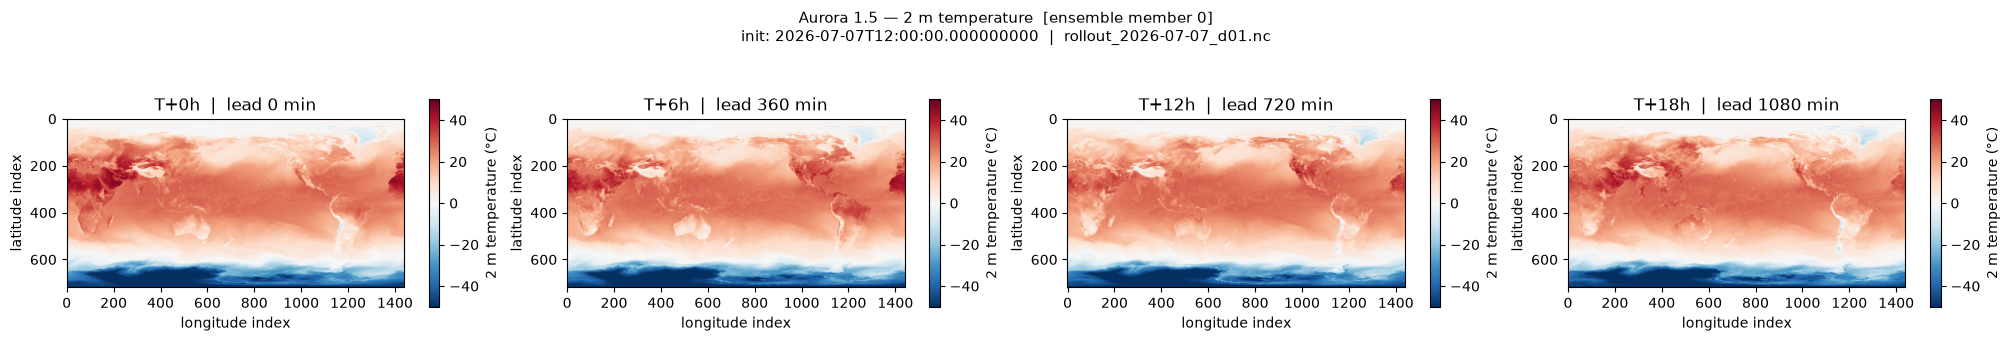

In [8]:
import matplotlib.pyplot as plt

if not rollout_results:
    print("No rollouts to visualise.")
else:
    # Visualise the first forecast day of the first init day.
    viz_path = rollout_results[0]["paths"][0]
    ds_viz = xr.open_dataset(viz_path, engine="netcdf4")

    # Select first ensemble member and first init_time for the spot-check.
    t2m = ds_viz["2t"].isel(ensemble=0, init_time=0)  # (lead_minutes, lat, lon)

    all_lead_m  = ds_viz["lead_minutes"].values
    # Show up to 4 evenly-spaced lead times within this file.
    sel_indices = list(range(0, len(all_lead_m), max(1, len(all_lead_m) // 4)))[:4]

    fig, axes = plt.subplots(
        1, len(sel_indices), figsize=(5 * len(sel_indices), 3.5), constrained_layout=True
    )
    if len(sel_indices) == 1:
        axes = [axes]

    init_val = ds_viz["init_time"].values[0]
    for ax, idx in zip(axes, sel_indices):
        field = t2m.isel(lead_minutes=idx).values - 273.15
        im    = ax.imshow(field, vmin=-50, vmax=50, cmap="RdBu_r", origin="upper")
        lm    = int(all_lead_m[idx])
        ax.set_title(f"T+{lm // 60}h  |  lead {lm} min")
        ax.set_xlabel("longitude index")
        ax.set_ylabel("latitude index")
        plt.colorbar(im, ax=ax, shrink=0.7, label="2 m temperature (°C)")

    member_label = "ensemble member 0" if USE_ENSEMBLE else "deterministic"
    fig.suptitle(
        f"Aurora 1.5 — 2 m temperature  [{member_label}]\ninit: {init_val}  |  {viz_path.name}",
        fontsize=11,
    )
    plt.show()
    ds_viz.close()